# CUNY Campuses Urban Tree Canopy Analysis

This notebook presents a focused analysis of urban tree canopy coverage across the City University of New York (CUNY) campuses. It includes data processing and spatial analysis to measure the total area of tree canopy on CUNY campuses, as well as the percentage of each area that is covered by canopy. The results are then explored through interactive visualizations, including charts and maps, to help better understand the spatial distribution and extent of tree coverage.



In [3]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", DeprecationWarning)


# 1. Upload Data and Calculate Tree Canopy Area and Coverage and Vizualization on CUNY campuses  

In [4]:
# Load GeoJSON into a GeoDataFrame
gdf = gpd.read_file("CUNY ALL 26 Campuse Polygons Enriched.geojson")

In [5]:
gdf.head()

,OBJECTID,title,F_id,amenity,name,type,building,height,nycdoitt_bin,short_name,...,building_part_1,roof_levels_1,start_date_1,branch_1,ele_1,gnis_feature_id_1,F1_phone,F1_website,F1_wikipedia,geometry
0,1,CUNY School of Professional Studies,1,None,CUNY School of Professional Studies,None,None,None,NaN,None,...,None,None,None,None,NaN,NaN,+1 212-652-CUNY,https://sps.cuny.edu/,https://en.wikipedia.org/wiki/CUNY_School_of_P...,"POLYGON ((-73.99014 40.7484, -73.98992 40.7483..."
1,2,CUNY School of Labor and Urban Studies,2,None,CUNY School of Labor & Urban Studies,None,None,None,NaN,None,...,None,None,None,None,NaN,NaN,+1 646-313-8300,https://slu.cuny.edu/,https://en.wikipedia.org/wiki/CUNY_School_of_L...,"POLYGON ((-73.98212 40.75499, -73.98204 40.754..."
2,3,CUNY Graduate School of Journalism,3,None,Craig Newmark Graduate School of Journalism at...,None,None,None,NaN,None,...,None,None,None,None,NaN,NaN,+1 646-758-7800,https://www.journalism.cuny.edu/,https://en.wikipedia.org/wiki/Craig_Newmark_Gr...,"POLYGON ((-73.98915 40.75536, -73.98884 40.755..."
3,4,CUNY Graduate School of Public Health & Health...,4,None,CUNY Graduate School of Public Health & Health...,None,None,None,NaN,None,...,None,None,None,None,NaN,NaN,+1 646-364-9600,https://sph.cuny.edu/,https://en.wikipedia.org/wiki/CUNY_Graduate_Sc...,"POLYGON ((-73.94449 40.80752, -73.94393 40.807..."
4,5,None,5,college,LaGuardia Community College,multipolygon,None,None,NaN,None,...,None,None,None,None,NaN,NaN,+1 718-482-7200,https://www.laguardia.edu,https://en.wikipedia.org/wiki/LaGuardia_Commun...,"MULTIPOLYGON (((-73.93678 40.74326, -73.93645 ..."


<Axes: >

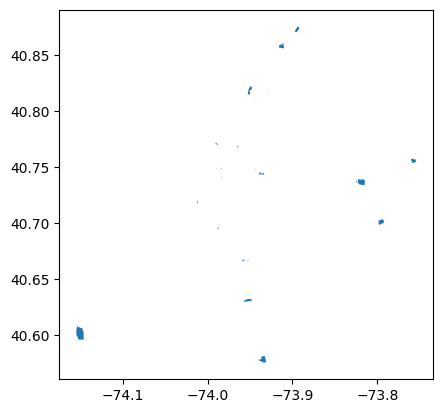

In [6]:
gdf.plot()

In [7]:
centroid = gdf.geometry.centroid
center_lat = centroid.y.mean()
center_lon = centroid.x.mean()

fig = px.choropleth_map(gdf,
                           geojson=gdf.geometry,
                           locations=gdf.index,
                           color='F_id',
                           color_discrete_sequence=['#1f77b4'],
                           map_style="carto-positron",
                           zoom=10,
                           opacity=0.45,
                           width=1200,
                           height=800,
                           hover_data=['name', 'F_id'],
                           title="CUNY Campuses",
                           labels={'F_id': 'Campus ID'},
                           center={"lat": center_lat, "lon": center_lon},
                           template="plotly_white",
                          )

fig.update_layout(margin={"r":0,"t":0,"l":0,"b":0})

fig.show()

In [8]:
import rasterio
from rasterio.mask import mask
import numpy as np
from matplotlib import pyplot
from rasterio.mask import mask
from shapely.geometry import box  # This is the missing import
import pandas as pd
from rasterio.crs import CRS
import rioxarray as rxr


# Load the raster dataset
raster_path = "NYC_Tree_Canopy_2_Feet_proj.tif"
with rasterio.open(raster_path) as src:
    raster_crs = src.crs  # Get raster coordinate reference system
    print(f"Raster CRS: {raster_crs}")
    print(src.res)
    array = src.read(1)


Raster CRS: EPSG:2263
(2.046046607988471, 2.0450054932892314)


In [9]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [10]:
gdf = gdf.to_crs(raster_crs)

In [11]:
import rasterio
from rasterio.mask import mask
from shapely.geometry import box
import numpy as np

# Open the raster (tree canopy coverage) file
with rasterio.open(raster_path) as src:
    raster_crs = src.crs  # Already EPSG:2263 (US survey feet)
    raster_bounds = src.bounds
    x_res, y_res = src.res  # Resolution in feet (2.046, 2.045)
    nodata = src.nodata  # Get actual NoData value from the raster

    # Calculate pixel area in square US survey feet
    pixel_area_ft2 = x_res * y_res  # ~2.046 * 2.045 ≈ 4.184 ft²

    # Ensure GeoDataFrame CRS matches the raster CRS (EPSG:2263)
    if gdf.crs != raster_crs:
        gdf = gdf.to_crs(raster_crs)

    # Bounding box of the raster for intersection checks
    raster_bbox = box(*raster_bounds)
    
    coverage_results = []

    # Loop through each campus polygon
    for index, row in gdf.iterrows():
        campus_name = row["name"]
        geometry = row.geometry
        total_area_ft2 = geometry.area  # Already in US survey ft² (CRS is EPSG:2263)

        # Skip if campus doesn't intersect the raster
        if not geometry.intersects(raster_bbox):
            print(f"Skipping {campus_name} – No intersection with raster.")
            continue

        try:
            # Mask the raster with the campus polygon
            out_image, out_transform = mask(src, [geometry], crop=True, nodata=nodata)
            out_image = out_image[0]  # First band

            # Identify valid pixels (inside campus, not NoData)
            valid_pixels_mask = (out_image != nodata)
            total_pixels_in_campus = np.count_nonzero(valid_pixels_mask)
            
            # Count canopy pixels (value == 1) within valid area
            canopy_pixels = np.count_nonzero(out_image[valid_pixels_mask] == 1)
            covered_area_ft2 = canopy_pixels * pixel_area_ft2

            # Calculate coverage percentage relative to TOTAL campus area
            coverage_percentage = (covered_area_ft2 / total_area_ft2) * 100 if total_area_ft2 > 0 else 0

            coverage_results.append({
                "campus": campus_name,
                "total_area_ft2": total_area_ft2,
                "covered_area_ft2": covered_area_ft2,
                "coverage_percentage": coverage_percentage
            })

        except Exception as e:
            print(f"Skipping {campus_name} due to error: {e}")
            continue

In [12]:
coverage_df = gpd.GeoDataFrame(coverage_results)

In [13]:
coverage_df

,campus,total_area_ft2,covered_area_ft2,coverage_percentage
0,CUNY School of Professional Studies,1.406515e+04,0.000000e+00,0.000000
1,CUNY School of Labor & Urban Studies,2.380810e+03,0.000000e+00,0.000000
2,Craig Newmark Graduate School of Journalism at...,1.000256e+04,0.000000e+00,0.000000
3,CUNY Graduate School of Public Health & Health...,1.588702e+04,3.138132e+02,1.975281
4,LaGuardia Community College,6.909312e+05,4.874147e+04,7.054461
5,Medgar Evers College,3.414389e+05,3.649857e+04,10.689635
6,New York City College of Technology,2.400443e+05,1.078262e+04,4.491930
7,Borough of Manhattan Community College,1.841038e+05,1.686223e+03,0.915909
8,Bronx Community College,1.819899e+06,3.549019e+05,19.501188
9,Hunter College,1.477650e+05,6.385053e+03,4.321087


In [14]:
# Format columns
coverage_df["total_area_ft2"] = coverage_df["total_area_ft2"].astype(int)  # Integer for area
coverage_df["covered_area_ft2"] = coverage_df["covered_area_ft2"].round(2)  # 2 decimals
coverage_df["coverage_percentage"] = coverage_df["coverage_percentage"].round(2)  # 2 decimals

In [15]:
merged_gdf = gdf.merge(coverage_df, left_on='name', right_on='campus')

In [26]:
merged_gdf.to_csv("CUNY_Campus_UrbanTreeCanopy.csv", index=False)

# 2. Data Viz

In [17]:
name_to_short = {
    'CUNY School of Professional Studies': 'SPS',
    'CUNY School of Labor & Urban Studies': 'SLU',
    'Craig Newmark Graduate School of Journalism at CUNY': 'Newmark J-School',
    'CUNY Graduate School of Public Health & Health Policy': 'SPH',
    'LaGuardia Community College': 'LaGuardia CC',
    'Medgar Evers College': 'Medgar Evers',
    'New York City College of Technology': 'City Tech',
    'Borough of Manhattan Community College': 'BMCC',
    'Bronx Community College': 'BCC',
    'Hunter College': 'Hunter',
    'City College of New York': 'CCNY',
    'Brooklyn College': 'Brooklyn',
    'Baruch College': 'Baruch',
    'CUNY Graduate School and University Center': 'Graduate Center',
    'John Jay College of Criminal Justice': 'John Jay',
    'Queens College': 'Queens',
    'Queensborough Community College': 'QCC',
    'York College': 'York',
    'Kingsborough Community College': 'KCC',
    'College of Staten Island': 'CSI',
    'Lehman College of the City University of New York': 'Lehman',
    'Eugenio Maria de Hostos Community College': 'Hostos',
    'CUNY School of Law': 'CUNY Law',
    'Macaulay Honors College': 'Macaulay',
    'CUNY Stella and Charles Guttman Community College': 'Guttman CC',
    'CUNY Advanced Science Research Center': 'ASRC'
}

# Map short names to the DataFrame
merged_gdf['shortname'] = merged_gdf['name'].map(name_to_short)

In [18]:
merged_gdf

,OBJECTID,title,F_id,amenity,name,type,building,height,nycdoitt_bin,short_name,...,gnis_feature_id_1,F1_phone,F1_website,F1_wikipedia,geometry,campus,total_area_ft2,covered_area_ft2,coverage_percentage,shortname
0,1,CUNY School of Professional Studies,1,None,CUNY School of Professional Studies,None,None,None,NaN,None,...,NaN,+1 212-652-CUNY,https://sps.cuny.edu/,https://en.wikipedia.org/wiki/CUNY_School_of_P...,"POLYGON ((986982.692 211938.678, 987041.69 211...",CUNY School of Professional Studies,14065,0.00,0.00,SPS
1,2,CUNY School of Labor and Urban Studies,2,None,CUNY School of Labor & Urban Studies,None,None,None,NaN,None,...,NaN,+1 646-313-8300,https://slu.cuny.edu/,https://en.wikipedia.org/wiki/CUNY_School_of_L...,"POLYGON ((989204.586 214339.161, 989226.642 21...",CUNY School of Labor & Urban Studies,2380,0.00,0.00,SLU
2,3,CUNY Graduate School of Journalism,3,None,Craig Newmark Graduate School of Journalism at...,None,None,None,NaN,None,...,NaN,+1 646-758-7800,https://www.journalism.cuny.edu/,https://en.wikipedia.org/wiki/Craig_Newmark_Gr...,"POLYGON ((987256.052 214476.041, 987340.78 214...",Craig Newmark Graduate School of Journalism at...,10002,0.00,0.00,Newmark J-School
3,4,CUNY Graduate School of Public Health & Health...,4,None,CUNY Graduate School of Public Health & Health...,None,None,None,NaN,None,...,NaN,+1 646-364-9600,https://sph.cuny.edu/,https://en.wikipedia.org/wiki/CUNY_Graduate_Sc...,"POLYGON ((999618.18 233484.843, 999771.078 233...",CUNY Graduate School of Public Health & Health...,15887,313.81,1.98,SPH
4,5,None,5,college,LaGuardia Community College,multipolygon,None,None,NaN,None,...,NaN,+1 718-482-7200,https://www.laguardia.edu,https://en.wikipedia.org/wiki/LaGuardia_Commun...,"MULTIPOLYGON (((1001767.93 210071.808, 1001859...",LaGuardia Community College,690931,48741.47,7.05,LaGuardia CC
5,6,None,6,university,Medgar Evers College,multipolygon,None,None,NaN,None,...,NaN,+1-718-270-4900,https://www.mec.cuny.edu,https://en.wikipedia.org/wiki/Medgar_Evers_Col...,"MULTIPOLYGON (((996165.286 181860.925, 996192....",Medgar Evers College,341438,36498.57,10.69,Medgar Evers
6,7,None,7,university,New York City College of Technology,multipolygon,None,None,NaN,None,...,NaN,+1-718-260-5000,https://www.citytech.cuny.edu,https://en.wikipedia.org/wiki/New_York_City_Co...,"MULTIPOLYGON (((987769.676 192500.45, 987770.8...",New York City College of Technology,240044,10782.62,4.49,City Tech
7,8,None,8,university,Borough of Manhattan Community College,multipolygon,yes,36.7,1066406.0,BMCC,...,NaN,+1 212-220-8000,https://www.bmcc.cuny.edu/,https://en.wikipedia.org/wiki/Borough_of_Manha...,"POLYGON ((981012.856 200745.017, 981080.354 20...",Borough of Manhattan Community College,184103,1686.22,0.92,BMCC
8,9,None,9,college,Bronx Community College,multipolygon,None,None,NaN,None,...,NaN,+1 718-289-5100,http://www.bcc.cuny.edu/,https://en.wikipedia.org/wiki/Bronx_Community_...,"MULTIPOLYGON (((1008994.974 251102.68, 1009039...",Bronx Community College,1819898,354901.86,19.50,BCC
9,10,None,10,college,Hunter College,None,None,None,NaN,None,...,NaN,+1 212-772-4000,https://hunter.cuny.edu,https://en.wikipedia.org/wiki/Hunter_College,"POLYGON ((993929.244 219448.762, 993826.247 21...",Hunter College,147764,6385.05,4.32,Hunter


In [19]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Convert results to DataFrame
coverage_df = pd.DataFrame(coverage_results)

# Create subplots (side-by-side histograms)
fig = make_subplots(rows=1, cols=2, subplot_titles=("Tree Canopy Area (ft²)", "Tree Canopy Coverage (%)"))

# Histogram for Canopy Area (ft²)
fig.add_trace(
    go.Histogram(
        x=coverage_df["covered_area_ft2"],
        nbinsx=20,
        name="Area (ft²)",
        marker_color='#2CA02C',
        hovertemplate="<b>%{x:,.0f} ft²</b><br>Count: %{y}<extra></extra>"
    ),
    row=1, col=1
)

# Histogram for Canopy Coverage (%)
fig.add_trace(
    go.Histogram(
        x=coverage_df["coverage_percentage"],
        nbinsx=20,
        name="Coverage (%)",
        marker_color='#1F77B4',
        hovertemplate="<b>%{x:.1f}%</b><br>Count: %{y}<extra></extra>"
    ),
    row=1, col=2
)

# Update layout
fig.update_layout(
    title_text="<b>Distribution of Tree Canopy Across CUNY Campuses</b>",
    title_x=0.5,
    showlegend=False,
    hoverlabel=dict(bgcolor="white", font_size=12),
    xaxis1=dict(title="Canopy Area (ft²)", tickformat=","),
    xaxis2=dict(title="Canopy Coverage (%)"),
    yaxis1=dict(title="Number of Campuses"),
    bargap=0.1
)

# Add median lines
median_area = coverage_df["covered_area_ft2"].median()
median_pct = coverage_df["coverage_percentage"].median()

fig.add_vline(x=median_area, line_dash="dot", line_color="red", row=1, col=1,
              annotation_text=f"Median: {median_area:,.0f} ft²", annotation_position="top")
fig.add_vline(x=median_pct, line_dash="dot", line_color="red", row=1, col=2,
              annotation_text=f"Median: {median_pct:.1f}%", annotation_position="top")

fig.show()

In [20]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Prepare data - merge names back into sorted DataFrames
coverage_df = merged_gdf
by_coverage = coverage_df.sort_values('coverage_percentage', ascending=False) 
by_area = coverage_df.sort_values('covered_area_ft2', ascending=False)

# Create vertical subplots with larger height
fig = make_subplots(
    rows=2, cols=1,
    vertical_spacing=0.3,
    subplot_titles=(
        "<b style='font-size:18px'>Canopy Coverage (%)</b>",
        "<b style='font-size:18px'>Canopy Area (ft²)</b>"
    ),
    row_heights=[0.5, 0.5]  # Equal height rows
)

# Top plot: Coverage % (with area in hover)
fig.add_trace(
    go.Bar(
        x=by_coverage['shortname'],
        y=by_coverage['coverage_percentage'],
        name='Coverage %',
        marker_color='#1f77b4',
        text=by_coverage['coverage_percentage'].apply(lambda x: f"{x:.1f}%"),
        textposition='outside',
        customdata=np.stack((
            by_coverage['campus'],  # Add campus names
            by_coverage['covered_area_ft2']  # Add area data
        ), axis=-1),
        hovertemplate=(
            #"<b>shortname: %{x}</b><br>"
            "<b>%{customdata[0]}</b><br>"
            "Coverage: %{y:.1f}%<br>"
            "Area: %{customdata[1]:,.0f} ft²<extra></extra>"
        )
    ),
    row=1, col=1
)

# Bottom plot: Area (with coverage % in hover)
fig.add_trace(
    go.Bar(
        x=by_area['shortname'],
        y=by_area['covered_area_ft2'],
        name='Area (ft²)',
        marker_color='#2ca02c',
        text=by_area['covered_area_ft2'].apply(lambda x: f"{x/1000:.0f}k"),
        textposition='outside',
        customdata=np.stack((
            by_area['campus'],  # Add campus names
            by_area['coverage_percentage']  # Add coverage data
        ), axis=-1),
        hovertemplate=(
            #"<b>F_id: %{x}</b><br>"
            "<b>%{customdata[0]}</b><br>"
            "Area: %{y:,.0f} ft²<br>"
            "Coverage: %{customdata[1]:.1f}%<extra></extra>"
        )
    ),
    row=2, col=1
)

# Add reference lines - using AVERAGE instead of MEDIAN for area
avg_vals = {
    'coverage': by_coverage['coverage_percentage'].mean(),
    'area': by_area['covered_area_ft2'].mean()
}
median_coverage = by_coverage['coverage_percentage'].median()

fig.add_hline(
    y=median_coverage,
    line_dash="dot",
    line_color="red",  # Soft red
    line_width=2,
    row=1, col=1,
    annotation_text=f"Median: {median_coverage:.1f}%",
    annotation_position="top right",
    annotation_font=dict(color='#333333')
)

fig.add_hline(
    y=avg_vals['area'],
    line_dash="dot",
    line_color="red",
    row=2, col=1,
    annotation_text=f"Average: {avg_vals['area']/1000:.1f}k ft²",
    annotation_position="top right"
)

# Update layout with x-axis labels
fig.update_layout(
    title_text="<b>CUNY Campus Tree Canopy Analysis</b><br>",
    title_x=0.5,
    title_font_size=20,
    showlegend=False,
    height=1200,  # Increased height
    hoverlabel=dict(
        bgcolor="white",
        font_size=14,
        font_family="Arial"
    ),
    xaxis1=dict(
        title="CUNY Campus",  # Added x-axis label
        tickangle=45,
        tickfont=dict(size=12)
    ),
    xaxis2=dict(
        title="CUNY Campus",  # Added x-axis label
        tickangle=45,
        tickfont=dict(size=12)
    ),
    yaxis1=dict(
        title="Coverage (%)",
        title_font_size=14,
        ticksuffix="%"
    ),
    yaxis2=dict(
        title="Tree Canopy Area (ft²)",
        title_font_size=14,
        tickformat=","
    ),
    margin=dict(b=120, t=120, l=80, r=40),
    plot_bgcolor='rgba(240,240,240,0.3)'
)

# Style traces
fig.update_traces(
    marker_line_color='rgba(0,0,0,0.5)',
    marker_line_width=1,
    opacity=0.9,
    textfont_size=12
)

fig.show()

In [21]:
# Save to HTML
fig.write_html(
    "cuny_tree_canopy_analysis.html",
    full_html=True,
    include_plotlyjs='cdn',
    config={
        'responsive': True,
        'displayModeBar': True
    },
    auto_open=True
)


# 3. Generate Maps

In [22]:
import rasterio
from rasterio.mask import mask
import numpy as np
import plotly.graph_objects as go
from shapely.geometry import box
from tqdm import tqdm
import plotly.graph_objects as go
from shapely.geometry import Polygon
from plotly.subplots import make_subplots

#top_10 = merged_gdf.nlargest(10, 'covered_area_ft2').copy()

gdf = merged_gdf.to_crs("4326")

raster_path_4236 = "tree_canopy_4326.tif"

In [23]:
# import plotly.graph_objects as go
# from plotly.subplots import make_subplots
# import plotly.express as px
# import warnings

# # Suppress warnings
# warnings.filterwarnings("ignore", category=UserWarning)

# MAPBOX_TOKEN = "pk.eyJ1IjoiZWxhZ2luIiwiYSI6ImNscTJndG9nYzAxaWgyaW9iZnd6ejFoc3QifQ.kEmANo4YElO2XI7IQf9mBA"

# # Create 3x3 subplot grid with mapbox type
# fig = make_subplots(
#     rows=5, cols=2,
#     subplot_titles=gdf["name"].tolist(),
#     specs=[[{'type': 'mapbox'}, {'type': 'mapbox'}] for _ in range(5)],
#     horizontal_spacing=0.05,
#     vertical_spacing=0.1
# )

# # Loop through first 10 polygons in gdf
# for i in range(10):
#     row = (i // 2) + 1
#     col = (i % 2) + 1
    
#     # Get the single polygon for this subplot
#     sub_gdf = gdf.iloc[[i]]
#     geojson = sub_gdf.geometry.__geo_interface__  # Correct GeoJSON extraction
    
#     # Create a choropleth mapbox for the polygon
#     choropleth = px.choropleth_mapbox(
#         sub_gdf,
#         geojson=geojson,
#         locations=sub_gdf.index,
#         color='coverage_percentage',
#         color_continuous_scale='Viridis',
#         opacity=0.5
#     )
    
#     # Add the trace to the subplot
#     for trace in choropleth.data:
#         fig.add_trace(trace, row=row, col=col)
    
#     # Configure each subplot's mapbox settings
#     centroid = sub_gdf.geometry.centroid.iloc[0]
#     fig.update_layout(
#         **{
#             f'mapbox{(i + 1)}': dict(
#                 accesstoken=MAPBOX_TOKEN,  # Required for Mapbox styles
#                 style="streets",  # Options: "light", "dark", "streets", "satellite-streets" (best for buildings)
#                 center=dict(lon=centroid.x, lat=centroid.y),
#                 zoom=14,  # Slightly higher zoom for building details
#             )
#         }
#     )

# # Add one shared colorbar
# fig.update_layout(
#     coloraxis=dict(colorscale='Viridis'),
#     coloraxis_colorbar=dict(
#         title='Tree Canopy Coverage (%)',
#         x=1.05,
#         len=0.8
#     ),
#     height=1600,
#     width=1400,
#     margin={"r":50, "t":120, "l":50, "b":50},
#     title_text="<b>CUNY Campuses with Highest Tree Canopy Coverage</b>",
#     title_x=0.5,
#     title_font=dict(size=24, family="Arial"),
#     title_pad=dict(t=20, b=40),
# )

# fig.show()

In [24]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy as np
import folium
from folium.plugins import Search
from PIL import Image
import io
import base64

# Load raster and vector data
with rasterio.open(raster_path_4236) as src:
    # Reproject campuses to raster CRS
    gdf = gdf.to_crs(src.crs)

    # Also make a projected version (feet) for buffering
    gdf_proj = gdf.to_crs(epsg=2263)

    # Neutral basemap, centered on NYC
    m = folium.Map(
        location=[40.7128, -74.0060],
        zoom_start=12,
        tiles='CartoDB positron'
    )

    # Inject CSS for legend, uniform font-family, and bump Search above zoom
    m.get_root().header.add_child(folium.Element("""
    <style>
      .info {
        padding: 6px 8px;
        font: 14px/16px Helvetica, sans-serif;
        background: rgba(255,255,255,0.9);
        box-shadow: 0 0 15px rgba(0,0,0,0.2);
        border-radius: 5px;
      }
      .info h4 {
        margin: 0 0 10px;
        color: #484747;
      }
      .legend {
        line-height: 18px;
        color: #555;
      }
      .legend i {
        width: 18px;
        height: 18px;
        float: left;
        margin-right: 8px;
        opacity: 0.7;
      }
      .leaflet-control-search {
        position: absolute;
        top: 10px !important;
        left: 10px !important;
        z-index: 1001;
      }
    </style>
    """))

    # Feature groups
    canopy_layer = folium.FeatureGroup(name="Canopy Cover")
    polygon_layer = folium.FeatureGroup(name="CUNY Campuses")

    buf_proj_full = gdf_proj.geometry.buffer(500)
    buf_geom_full = gpd.GeoSeries([buf_proj_full.unary_union], crs=gdf_proj.crs) \
              .to_crs(src.crs)

    for i, row in gdf.iterrows():
    
        try:
            # 1) Buffer in projected CRS by 500 m
            buf_proj = gdf_proj.geometry.iloc[i].buffer(300)

            # 2) Reproject buffer back to raster CRS
            buf_geom = gpd.GeoSeries([buf_proj], crs=gdf_proj.crs) \
                          .to_crs(src.crs).iloc[0]

            # 3) Crop the canopy raster by the individual campus buffer
            out_image, out_transform = mask(src, [buf_geom], crop=True)
            array = out_image[0]

            # 4) Build RGBA overlay for canopy
            mask_canopy = (array == 1)
            img_rgba = np.zeros((array.shape[0], array.shape[1], 4), dtype=np.uint8)
            img_rgba[mask_canopy] = [34, 139, 34, 180]  # forest green

            img = Image.fromarray(img_rgba, mode="RGBA")
            buf = io.BytesIO()
            img.save(buf, format="PNG")
            b64 = base64.b64encode(buf.getvalue()).decode()

            # 5) Compute bounds of the cropped image
            sw = rasterio.transform.xy(out_transform, array.shape[0], 0, offset='center')
            ne = rasterio.transform.xy(out_transform, 0, array.shape[1], offset='center')
            bounds = [[sw[1], sw[0]], [ne[1], ne[0]]]

            # 6) Add canopy overlay (drawn second so it's on top)
            folium.raster_layers.ImageOverlay(
                image=f"data:image/png;base64,{b64}",
                bounds=bounds,
                opacity=1,
                name="Canopy Cover"
            ).add_to(canopy_layer)

            # 7) Add the original campus polygon with hover tooltip
            feature = {
                "type": "Feature",
                "properties": {
                    "name": row.get("name", "N/A"),
                    "coverage_percentage": row.get("coverage_percentage", "N/A"),
                    "covered_area_ft2": row.get("covered_area_ft2", "N/A")
                },
                "geometry": row.geometry.__geo_interface__
            }

            folium.GeoJson(
                feature,
                style_function=lambda feat: {
                    'fillColor': 'lightblue',
                    'color': 'darkblue',
                    'weight': 2,
                    'opacity': 0.9,
                    'fillOpacity': 0.1  # semi‑transparent
                },
                highlight_function=lambda feat: {
                    'weight': 5,
                    'color': 'darkblue',
                    'fillOpacity': 0.6  # more opaque on hover
                },
                tooltip=folium.GeoJsonTooltip(
                    fields=["name", "coverage_percentage", "covered_area_ft2"],
                    aliases=["Name:", "Tree Canopy Coverage (%):", "Tree Canopy Area (ft²):"],
                    localize=True,
                    style=("""
                    background-color: rgba(255,255,255,0.9);
                    border-radius: 3px;
                    box-shadow: 3px 3px 10px rgba(0, 0, 0, 0.2);
                    font-family: Helvetica, sans-serif;
                    font-size: 12px;
                    padding: 8px;
                """)
                )
            ).add_to(polygon_layer)

        except ValueError as e:
            print(f"Campus {i} skipped: {e}")

    # Draw polygon first, then canopy so canopy is on top
    polygon_layer.add_to(m)
    canopy_layer.add_to(m)
    folium.LayerControl().add_to(m)

    # Search control for campuses
    Search(
        layer=polygon_layer,
        geom_type="Polygon",
        placeholder="Search CUNY Campus",
        collapsed=True,
        search_label="name",
        position='topleft'
    ).add_to(m)

    # Legend with two entries, spaced and bottom-right
    m.get_root().html.add_child(folium.Element("""
    <div class="info legend" style="
        position: fixed;
        bottom: 50px;
        right: 50px;
        z-index:9999;
    ">
      <i style="background: #228B22"></i> Tree Canopy<br><br>
      <i style="background: rgba(173, 216, 230, 0.1); border:2px solid darkblue;"></i> CUNY Campus Boundary
    </div>
    """))



In [25]:
m.save("tree_canopy_map_nyc_final.html")